# 🖥️ Laptop Scrap Data — Full Analytics & ML Pipeline

**Sections:**
1. Data Loading & Inspection
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA) — Matplotlib & Seaborn
4. Interactive Visualisations — Plotly
5. Feature Engineering & Model Training (Regression)
6. Clustering Analysis (K-Means)
7. Real-Time Analytical Dashboard (Plotly Dash)
8. PostgreSQL DDL & Data Insertion Script

## 1. 📦 Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42

print('✅ All imports successful')

Matplotlib is building the font cache; this may take a moment.


✅ All imports successful


## 2. 📂 Data Loading & Initial Inspection

In [3]:
df_raw = pd.read_csv('laptop_scrap_data.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (1563, 21)


,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price
0,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra X7 358H,Intel Arc B390,Windows,0.0,0.0,2880.0,...,212.26,1.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2728.8
1,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra 9 386H,Intel Graphics (4-Cores),Windows,0.0,0.0,2880.0,...,212.26,0.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2528.8
2,ASUS,ASUS Vivobook S16,16.0,1920 x 1200,AMD Ryzen AI 5 330,AMD Radeon 820M,Windows,0.0,0.0,1920.0,...,141.51,1.0,24.0,1.70,4000.0,0.0,SSD Only,4000.0,Very High (> 2TB),2428.8
3,Toshiba,Dynabook X series,13.3,1920 x 1200,Intel Core i5-1350P,Intel Iris Xe Graphics G7 (80EU),Windows,1.0,1.0,1920.0,...,170.24,0.0,16.0,0.93,512.0,0.0,SSD Only,512.0,Standard (512GB-1TB),1390.2
4,Lenovo,"Lenovo Legion 5a (15"", Gen 11, 15AGP11)",15.3,2560 x 1600,AMD Ryzen AI 9 465,NVIDIA GeForce RTX 5060 (Laptop),Windows,0.0,0.0,2560.0,...,197.31,1.0,32.0,1.87,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2067.8


In [4]:
print('=== Column Data Types ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print()
print('=== Duplicate Rows ===')
print(df_raw.duplicated().sum())

=== Column Data Types ===
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Gpu                  object
OpSys                object
TouchScreen         float64
Ips                 float64
X_res               float64
Y_res               float64
ppi                 float64
Dedicated_Gpu       float64
Ram_GB              float64
Weight_kg           float64
SSD                 float64
HHD                 float64
Storage_Type         object
Total_Storage_GB    float64
Storage_Category     object
Price               float64
dtype: object

=== Missing Values ===
Company             3
TypeName            3
Inches              3
ScreenResolution    3
Cpu                 3
Gpu                 3
OpSys               3
TouchScreen         3
Ips                 3
X_res               3
Y_res               3
ppi                 3
Dedicated_Gpu       3
Ram_GB              3
Weight_kg           3
SSD               

In [ ]:
df_raw.describe()

## 3. 🧹 Data Cleaning & Preprocessing

In [5]:
df = df_raw.copy()

# Drop rows where ALL values are null (3 sentinel rows)
df.dropna(how='all', inplace=True)
# Drop any remaining rows with nulls in key numeric columns
df.dropna(subset=['Price', 'Ram_GB', 'Weight_kg', 'Total_Storage_GB', 'ppi'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix types
for col in ['TouchScreen', 'Ips', 'Dedicated_Gpu']:
    df[col] = df[col].astype(int)

# Remove rows with zero/negative Price or Storage anomalies
df = df[df['Price'] > 0]
df = df[df['Total_Storage_GB'] > 0]

# Clean Storage_Category: replace 'No Data' with mode
mode_cat = df[df['Storage_Category'] != 'No Data']['Storage_Category'].mode()[0]
df['Storage_Category'] = df['Storage_Category'].replace('No Data', mode_cat)

# Extract brand family from Cpu
def cpu_brand(cpu):
    if pd.isna(cpu): return 'Other'
    cpu = cpu.lower()
    if 'intel' in cpu: return 'Intel'
    if 'amd' in cpu: return 'AMD'
    if 'apple' in cpu: return 'Apple'
    if 'qualcomm' in cpu: return 'Qualcomm'
    return 'Other'

df['Cpu_Brand'] = df['Cpu'].apply(cpu_brand)

# GPU brand
def gpu_brand(gpu):
    if pd.isna(gpu): return 'Other'
    gpu = gpu.lower()
    if 'nvidia' in gpu: return 'NVIDIA'
    if 'amd' in gpu or 'radeon' in gpu: return 'AMD'
    if 'intel' in gpu: return 'Intel'
    if 'apple' in gpu: return 'Apple'
    return 'Other'

df['Gpu_Brand'] = df['Gpu'].apply(gpu_brand)

# Price tier
df['Price_Tier'] = pd.cut(df['Price'],
    bins=[0, 800, 1300, 1800, 2500, 10000],
    labels=['Budget', 'Entry', 'Mid-Range', 'High-End', 'Premium'])

# Screen size category
df['Screen_Size_Cat'] = pd.cut(df['Inches'],
    bins=[0, 13.5, 14.5, 15.9, 18],
    labels=['Compact (≤13")', 'Standard 14"', 'Standard 15-16"', 'Large 17+"'])

print(f'Clean shape: {df.shape}')
df.head()

Clean shape: (1559, 25)


,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price,Cpu_Brand,Gpu_Brand,Price_Tier,Screen_Size_Cat
0,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra X7 358H,Intel Arc B390,Windows,0,0,2880.0,...,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2728.8,Intel,Intel,Premium,"Large 17+"""
1,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra 9 386H,Intel Graphics (4-Cores),Windows,0,0,2880.0,...,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2528.8,Intel,Intel,Premium,"Large 17+"""
2,ASUS,ASUS Vivobook S16,16.0,1920 x 1200,AMD Ryzen AI 5 330,AMD Radeon 820M,Windows,0,0,1920.0,...,4000.0,0.0,SSD Only,4000.0,Very High (> 2TB),2428.8,AMD,AMD,High-End,"Large 17+"""
3,Toshiba,Dynabook X series,13.3,1920 x 1200,Intel Core i5-1350P,Intel Iris Xe Graphics G7 (80EU),Windows,1,1,1920.0,...,512.0,0.0,SSD Only,512.0,Standard (512GB-1TB),1390.2,Intel,Intel,Mid-Range,"Compact (≤13"")"
4,Lenovo,"Lenovo Legion 5a (15"", Gen 11, 15AGP11)",15.3,2560 x 1600,AMD Ryzen AI 9 465,NVIDIA GeForce RTX 5060 (Laptop),Windows,0,0,2560.0,...,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2067.8,AMD,NVIDIA,High-End,"Standard 15-16"""


## 4. 📊 Exploratory Data Analysis — Matplotlib & Seaborn

### 4.1 Price Distribution

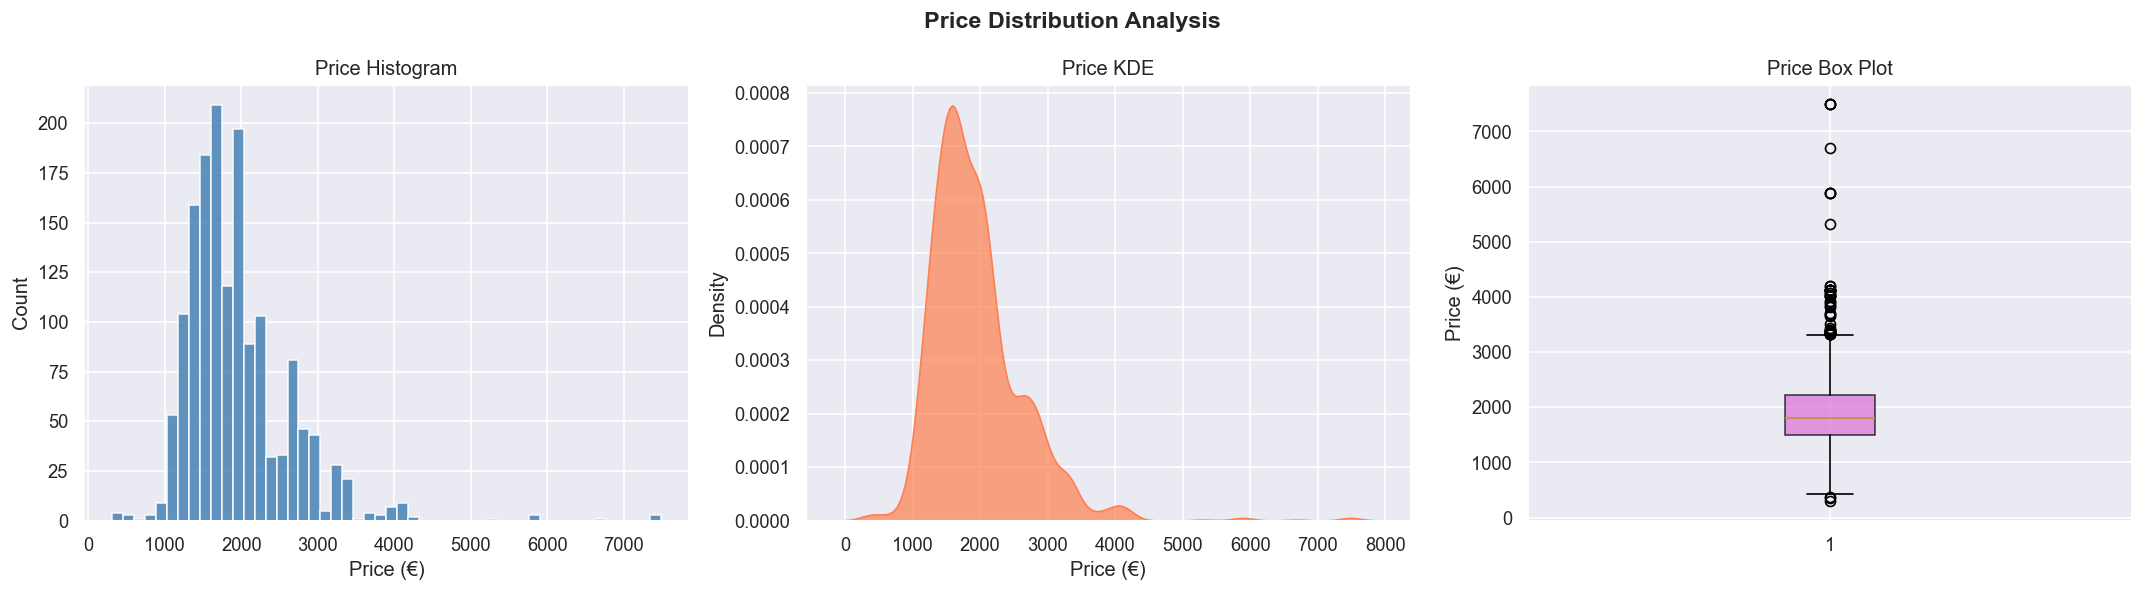

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Price Distribution Analysis', fontsize=14, fontweight='bold')

axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Histogram')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')

sns.kdeplot(df['Price'], ax=axes[1], fill=True, color='coral', alpha=0.7)
axes[1].set_title('Price KDE')
axes[1].set_xlabel('Price (€)')

axes[2].boxplot(df['Price'], vert=True, patch_artist=True,
    boxprops=dict(facecolor='orchid', alpha=0.7))
axes[2].set_title('Price Box Plot')
axes[2].set_ylabel('Price (€)')

plt.tight_layout()
plt.show()

### 4.2 Brand Analysis

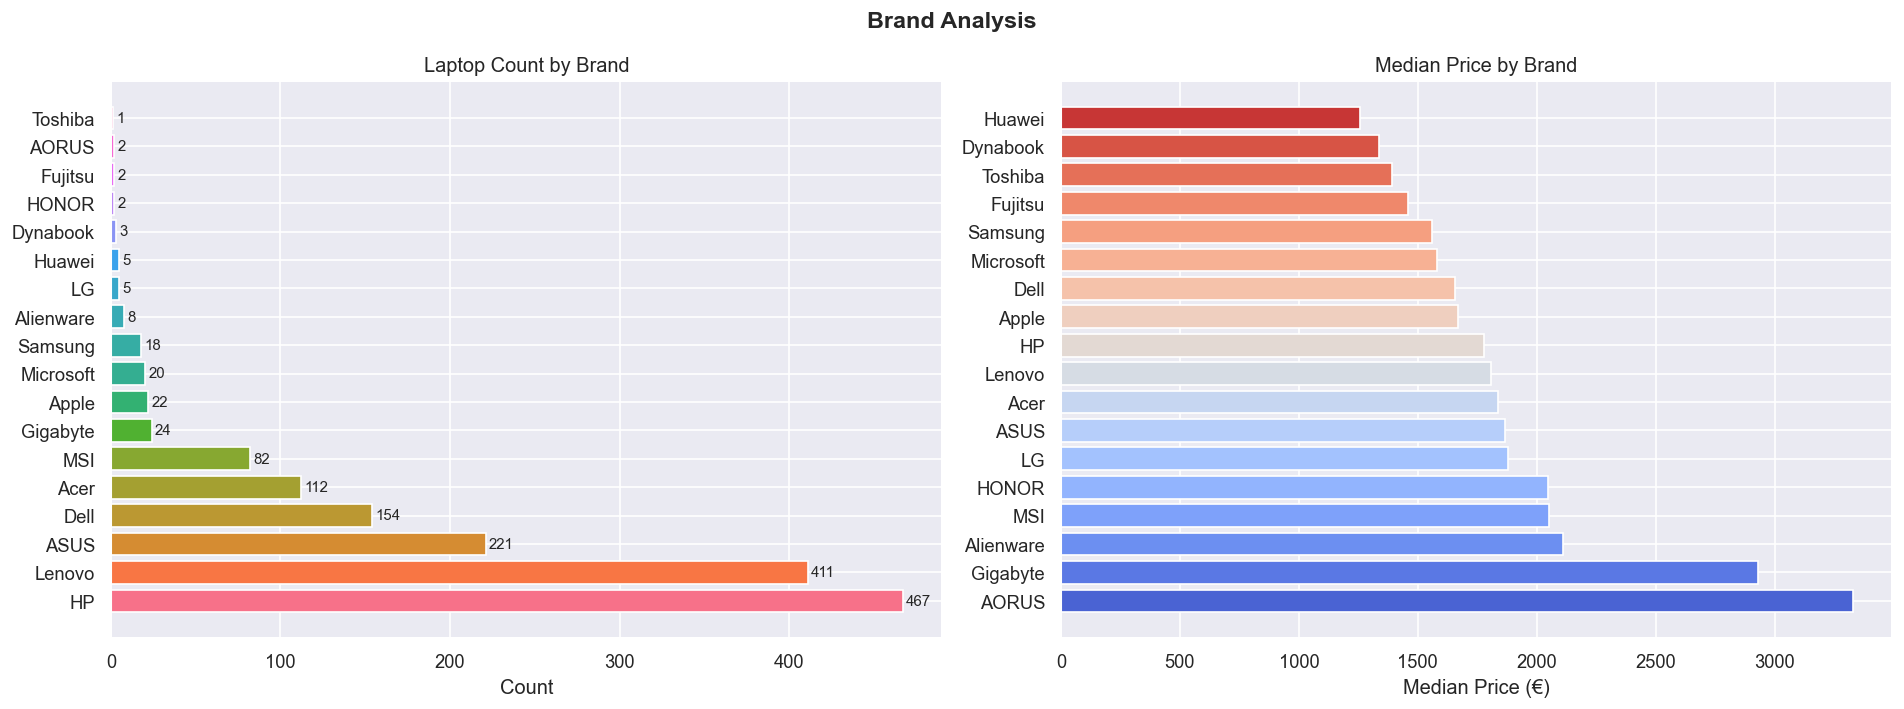

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Brand Analysis', fontsize=14, fontweight='bold')

brand_counts = df['Company'].value_counts()
colors = sns.color_palette('husl', len(brand_counts))
axes[0].barh(brand_counts.index, brand_counts.values, color=colors)
axes[0].set_title('Laptop Count by Brand')
axes[0].set_xlabel('Count')
for i, (v, label) in enumerate(zip(brand_counts.values, brand_counts.index)):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=9)

brand_price = df.groupby('Company')['Price'].median().sort_values(ascending=False)
axes[1].barh(brand_price.index, brand_price.values,
    color=sns.color_palette('coolwarm', len(brand_price)))
axes[1].set_title('Median Price by Brand')
axes[1].set_xlabel('Median Price (€)')

plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

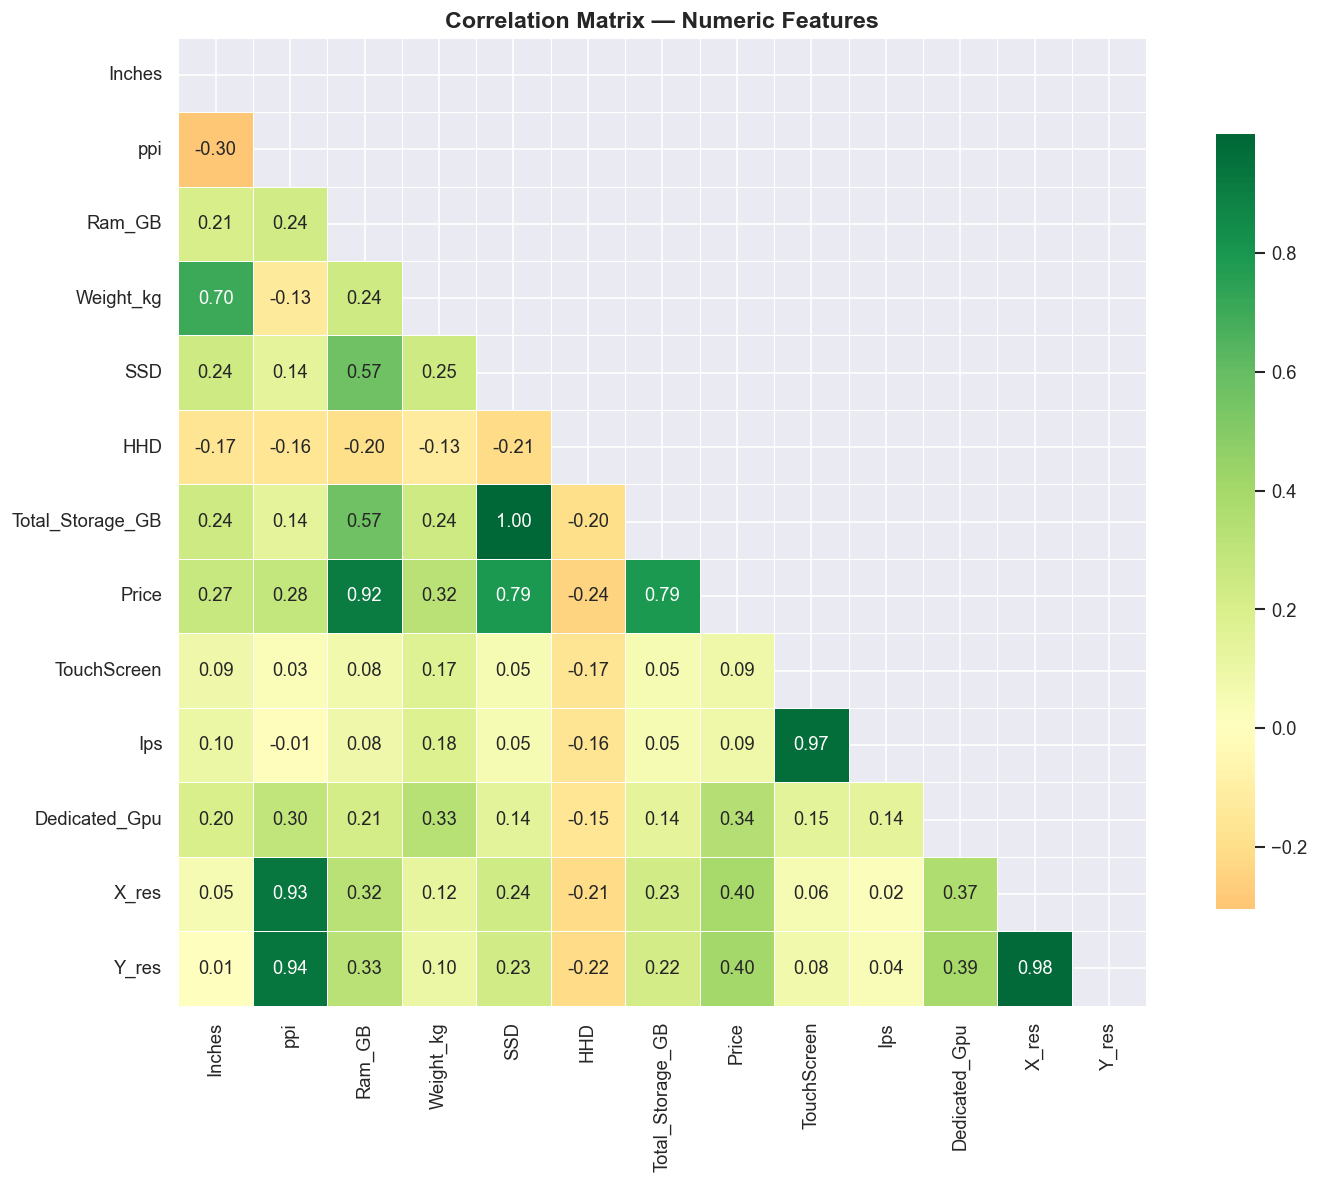

In [8]:
num_cols = ['Inches', 'ppi', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD',
            'Total_Storage_GB', 'Price', 'TouchScreen', 'Ips',
            'Dedicated_Gpu', 'X_res', 'Y_res']

corr = df[num_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 RAM, Storage, GPU vs Price

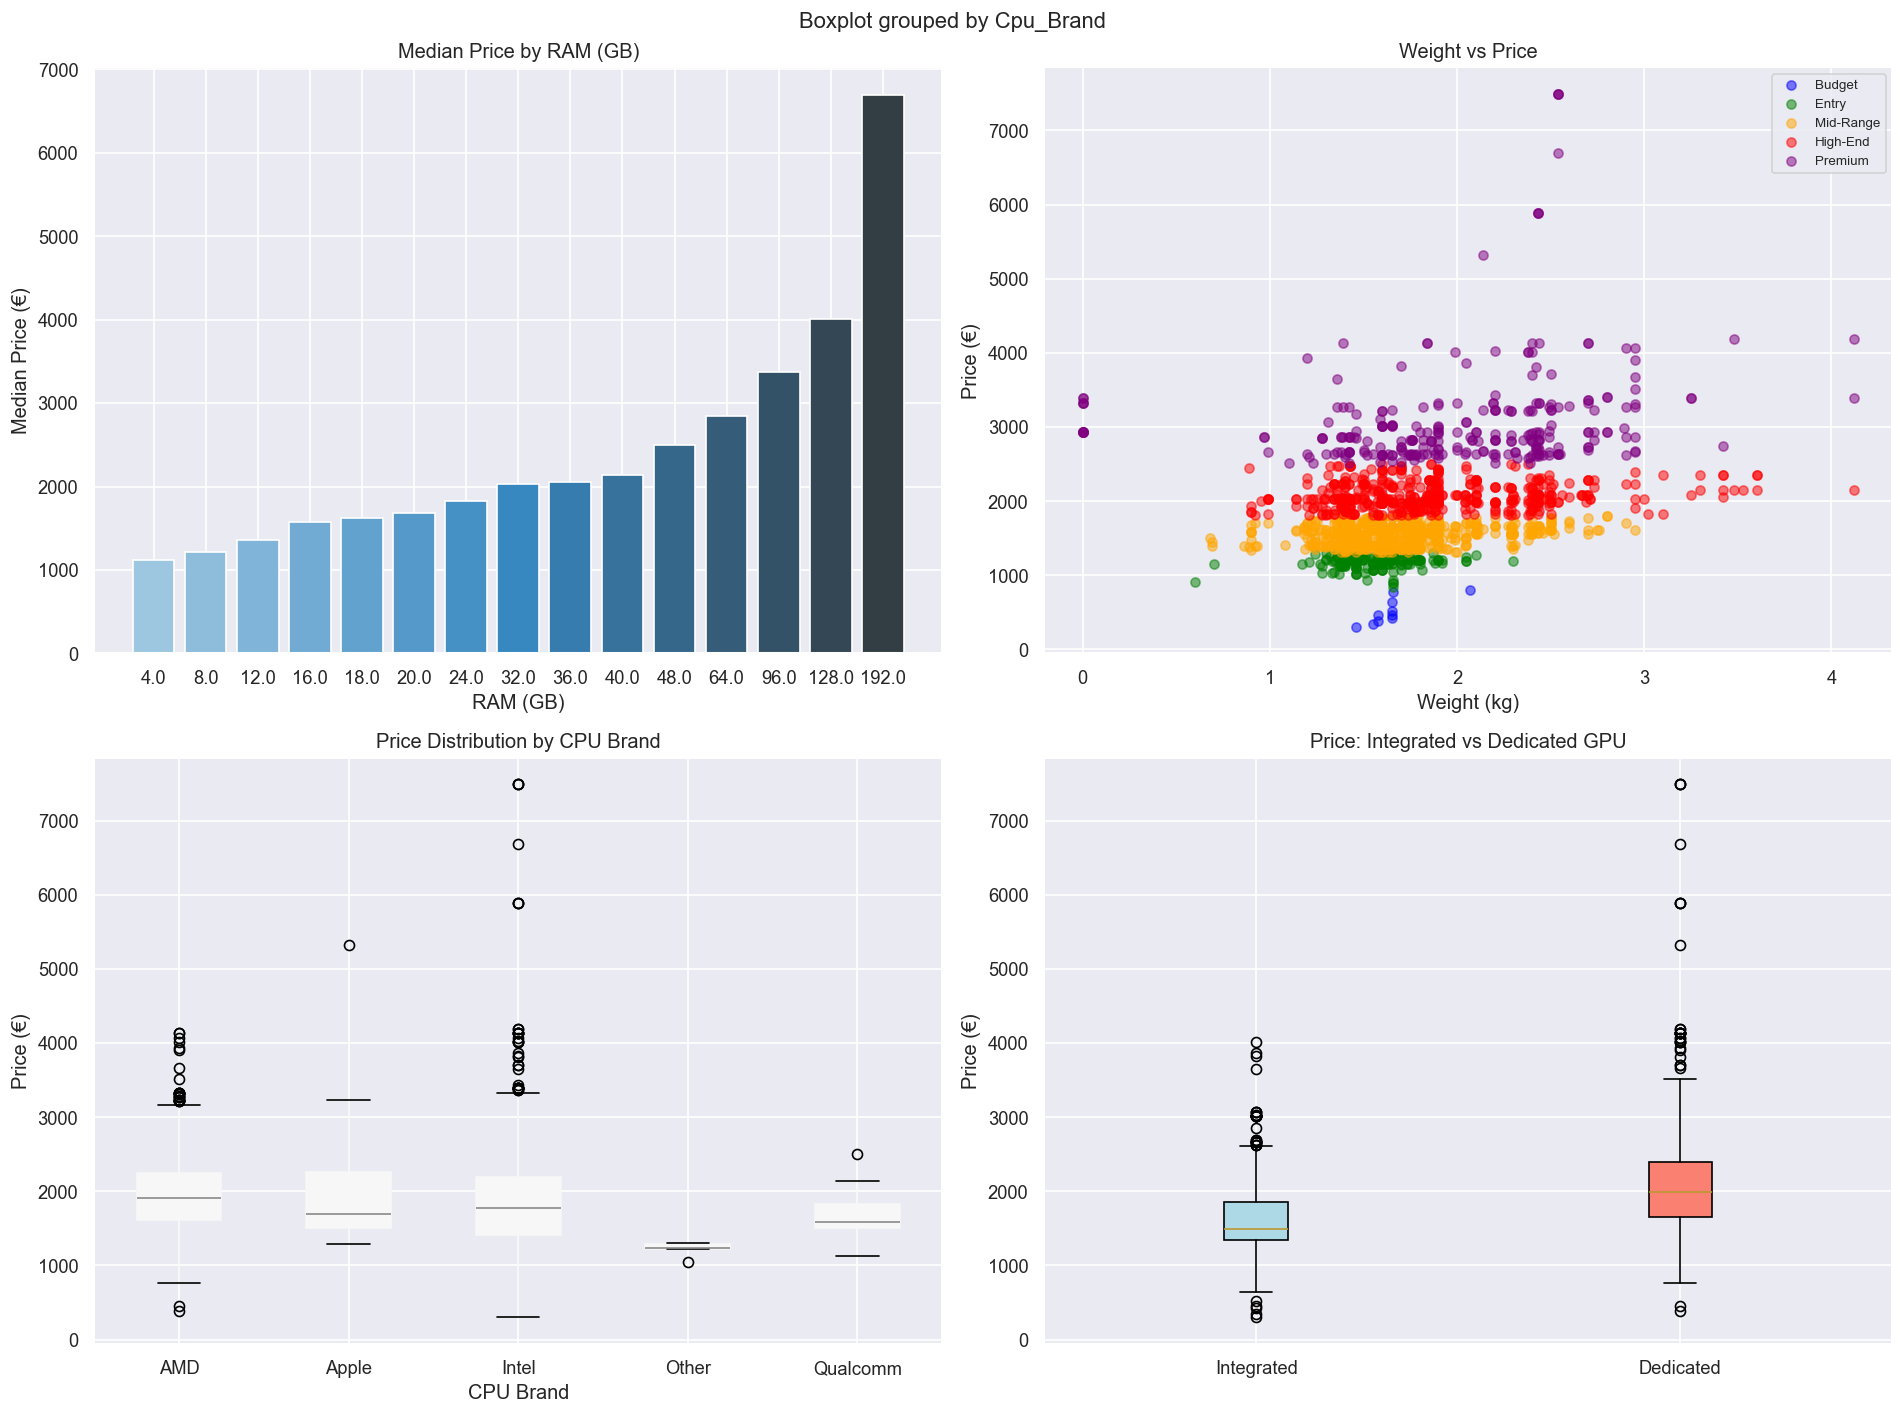

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature vs Price Analysis', fontsize=14, fontweight='bold')

# RAM vs Price
ram_price = df.groupby('Ram_GB')['Price'].median().reset_index()
axes[0, 0].bar(ram_price['Ram_GB'].astype(str), ram_price['Price'],
               color=sns.color_palette('Blues_d', len(ram_price)))
axes[0, 0].set_title('Median Price by RAM (GB)')
axes[0, 0].set_xlabel('RAM (GB)')
axes[0, 0].set_ylabel('Median Price (€)')

# Weight vs Price scatter
scatter_colors = {'Budget': 'blue', 'Entry': 'green',
                  'Mid-Range': 'orange', 'High-End': 'red', 'Premium': 'purple'}
for tier, grp in df.groupby('Price_Tier', observed=True):
    axes[0, 1].scatter(grp['Weight_kg'], grp['Price'], label=tier,
                       alpha=0.5, s=30, color=scatter_colors.get(tier, 'gray'))
axes[0, 1].set_title('Weight vs Price')
axes[0, 1].set_xlabel('Weight (kg)')
axes[0, 1].set_ylabel('Price (€)')
axes[0, 1].legend(fontsize=8)

# CPU Brand vs Price
df.boxplot(column='Price', by='Cpu_Brand', ax=axes[1, 0],
           patch_artist=True)
axes[1, 0].set_title('Price Distribution by CPU Brand')
axes[1, 0].set_xlabel('CPU Brand')
axes[1, 0].set_ylabel('Price (€)')
plt.sca(axes[1, 0])
plt.title('Price Distribution by CPU Brand')

# Dedicated GPU vs Price
gpu_labels = {0: 'Integrated', 1: 'Dedicated'}
gpu_data = [df[df['Dedicated_Gpu'] == 0]['Price'],
            df[df['Dedicated_Gpu'] == 1]['Price']]
bp = axes[1, 1].boxplot(gpu_data, labels=['Integrated', 'Dedicated'],
                         patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('salmon')
axes[1, 1].set_title('Price: Integrated vs Dedicated GPU')
axes[1, 1].set_ylabel('Price (€)')

plt.tight_layout()
plt.show()

### 4.5 OS, Touch & IPS Analysis

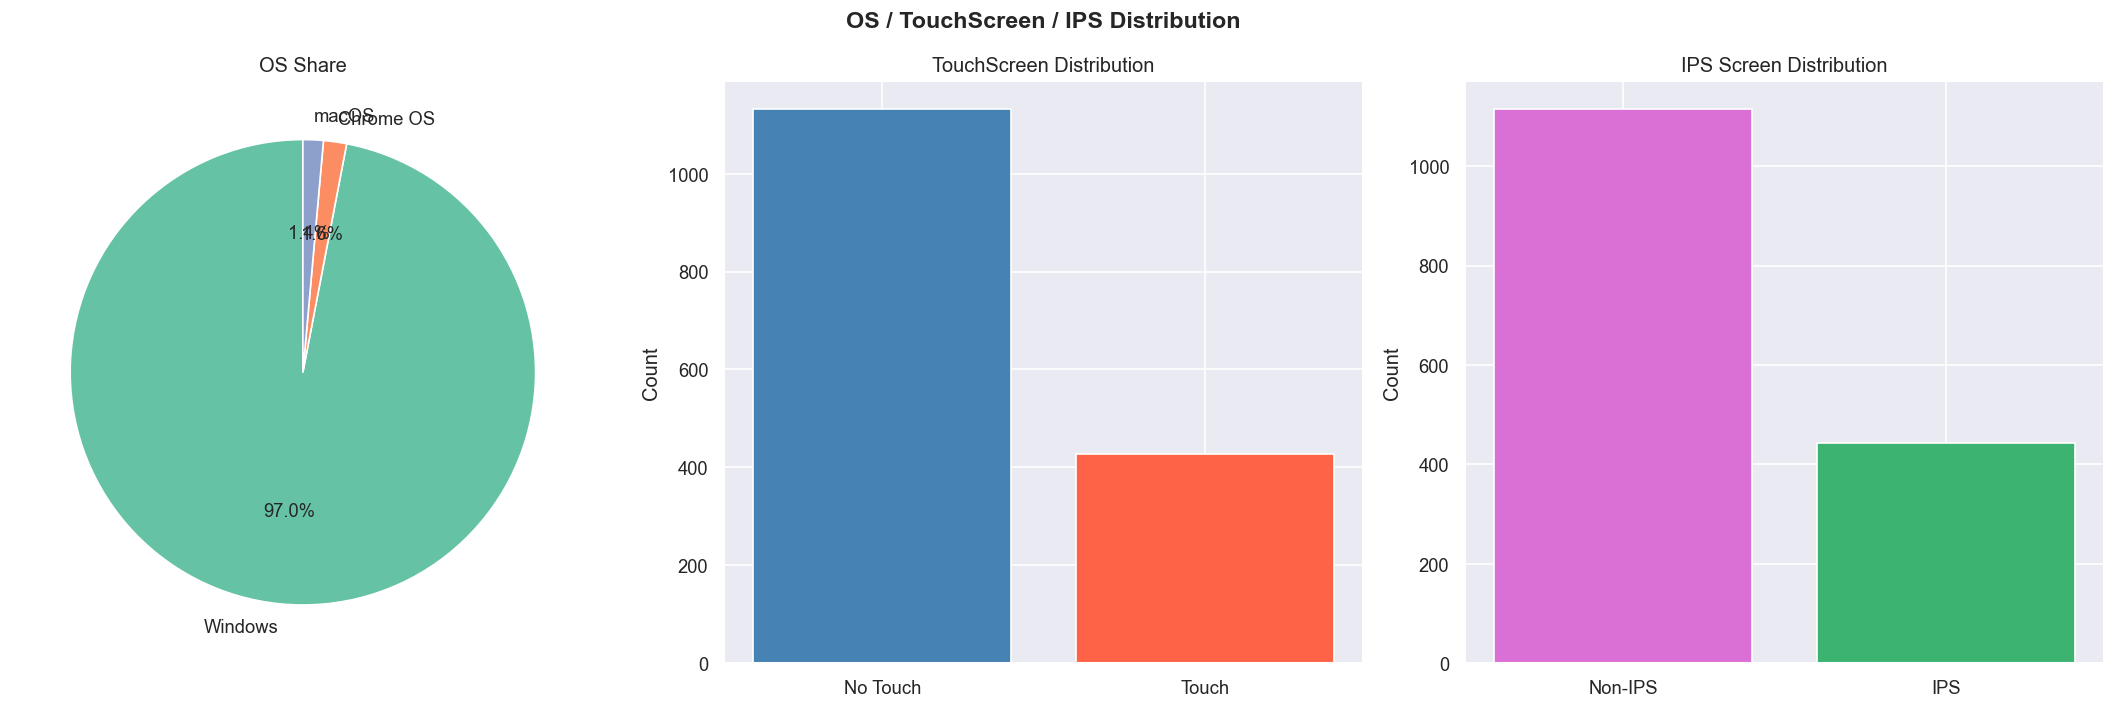

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('OS / TouchScreen / IPS Distribution', fontsize=14, fontweight='bold')

os_data = df['OpSys'].value_counts()
axes[0].pie(os_data.values, labels=os_data.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(os_data)), startangle=90)
axes[0].set_title('OS Share')

touch_data = df['TouchScreen'].value_counts()
axes[1].bar(['No Touch', 'Touch'], touch_data.values,
            color=['steelblue', 'tomato'])
axes[1].set_title('TouchScreen Distribution')
axes[1].set_ylabel('Count')

ips_data = df['Ips'].value_counts()
axes[2].bar(['Non-IPS', 'IPS'], ips_data.values,
            color=['orchid', 'mediumseagreen'])
axes[2].set_title('IPS Screen Distribution')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 4.6 Price Tier & Storage Category Distribution

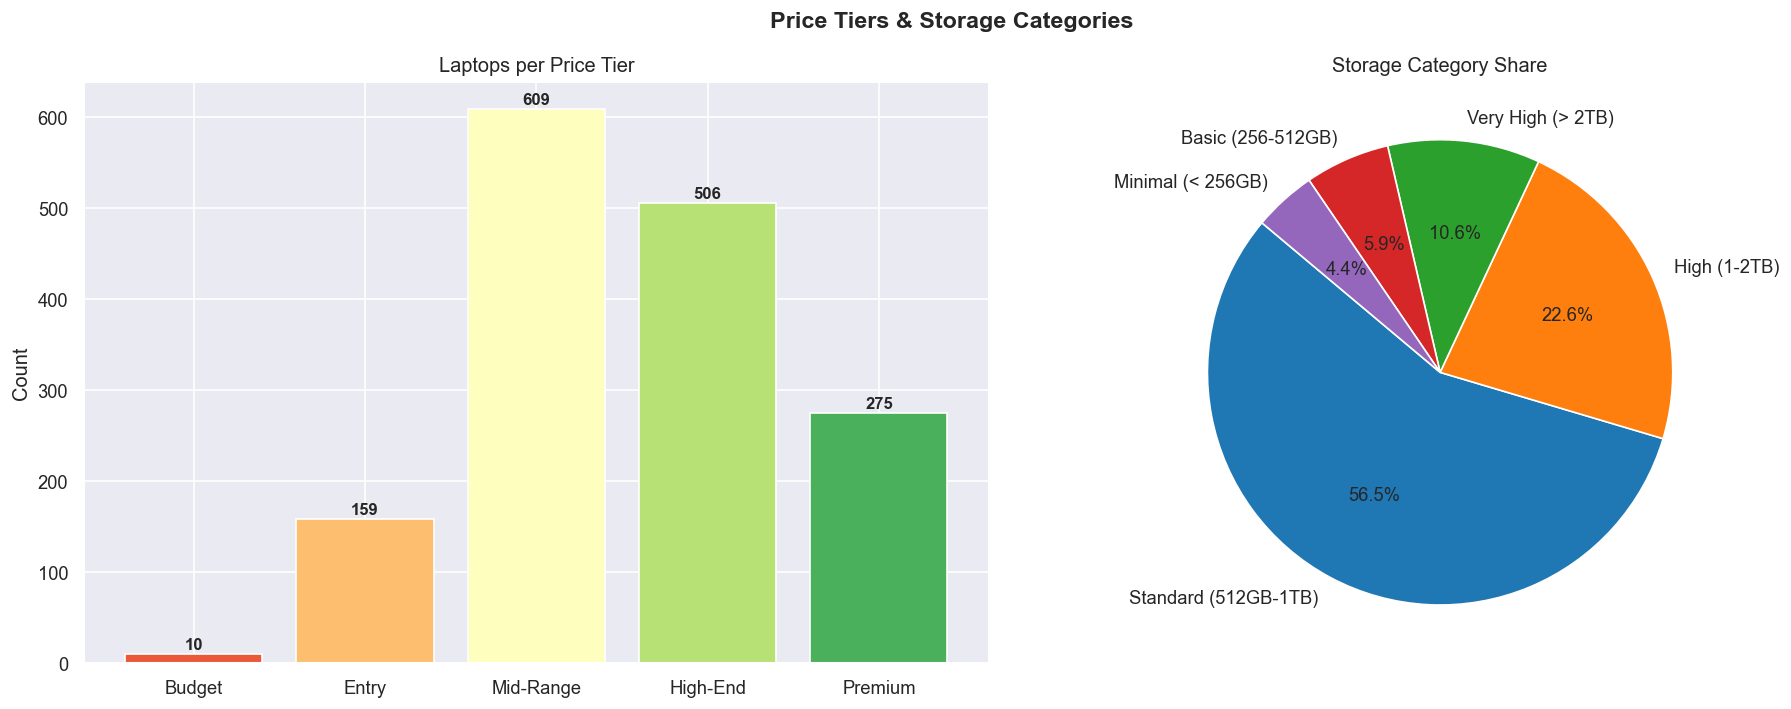

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Price Tiers & Storage Categories', fontsize=14, fontweight='bold')

tier_counts = df['Price_Tier'].value_counts().sort_index()
bars = axes[0].bar(tier_counts.index, tier_counts.values,
                   color=sns.color_palette('RdYlGn', len(tier_counts)))
for bar, val in zip(bars, tier_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Laptops per Price Tier')
axes[0].set_ylabel('Count')

stor_counts = df['Storage_Category'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    stor_counts.values, labels=stor_counts.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('tab10', len(stor_counts)))
axes[1].set_title('Storage Category Share')

plt.tight_layout()
plt.show()

### 4.7 Violin Plots — Price by Brand (top 8)

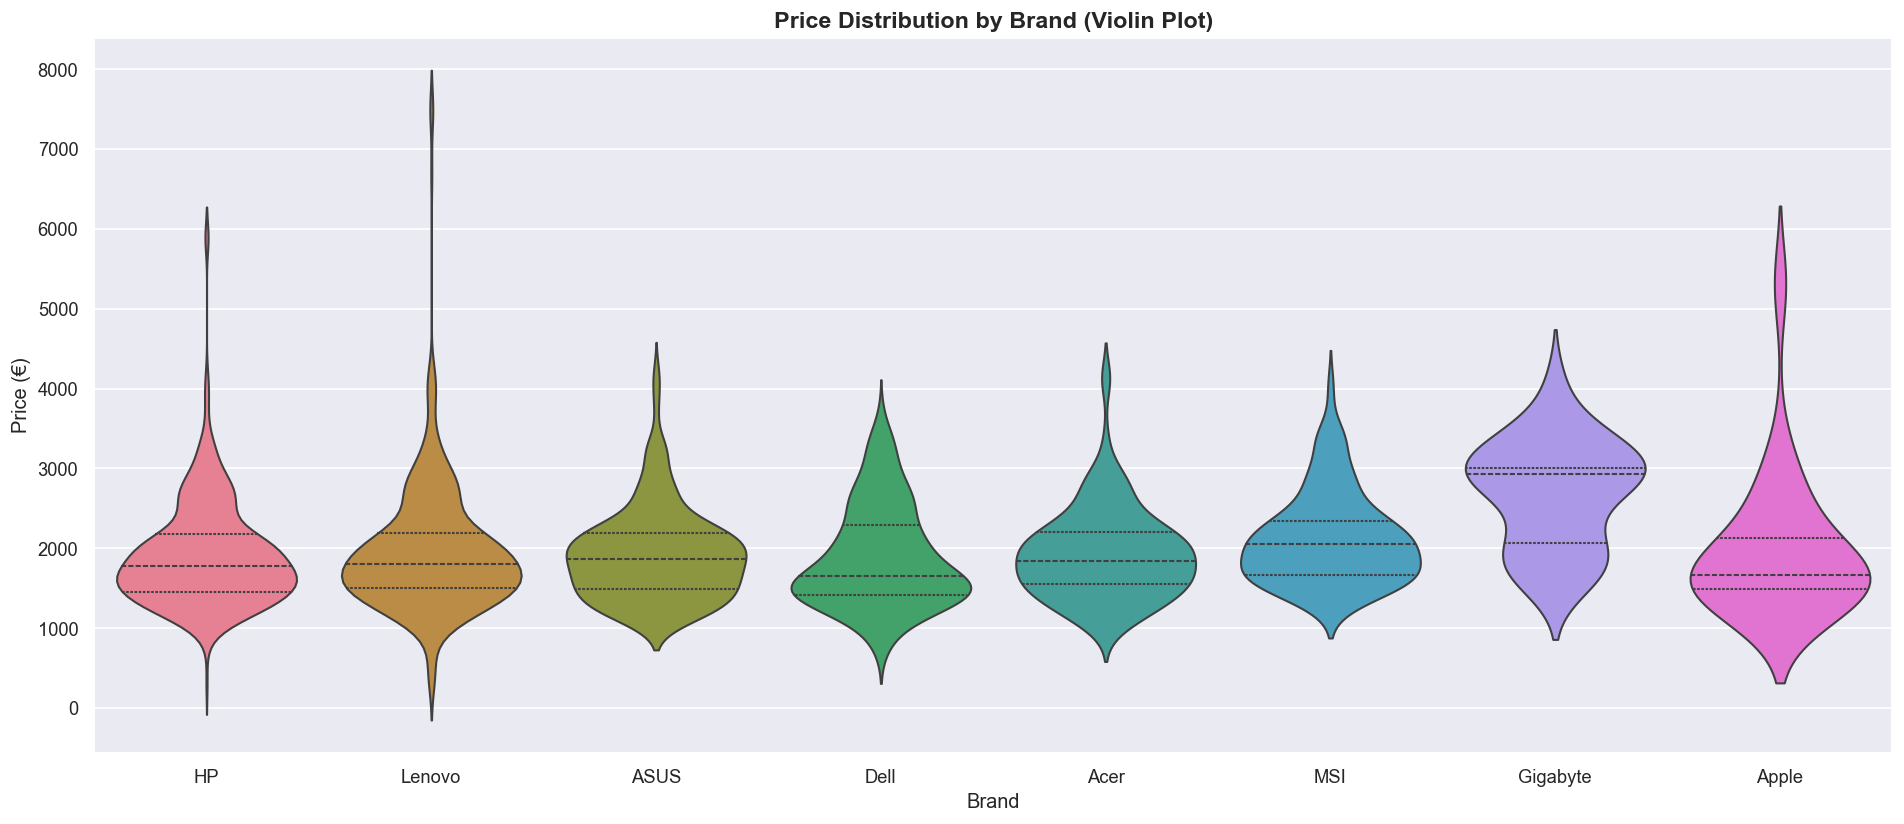

In [12]:
top_brands = df['Company'].value_counts().head(8).index.tolist()
df_top = df[df['Company'].isin(top_brands)]

plt.figure(figsize=(16, 7))
sns.violinplot(data=df_top, x='Company', y='Price', palette='husl',
               order=top_brands, inner='quartile')
plt.title('Price Distribution by Brand (Violin Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Price (€)')
plt.tight_layout()
plt.show()

### 4.8 PPI & Screen Resolution Analysis

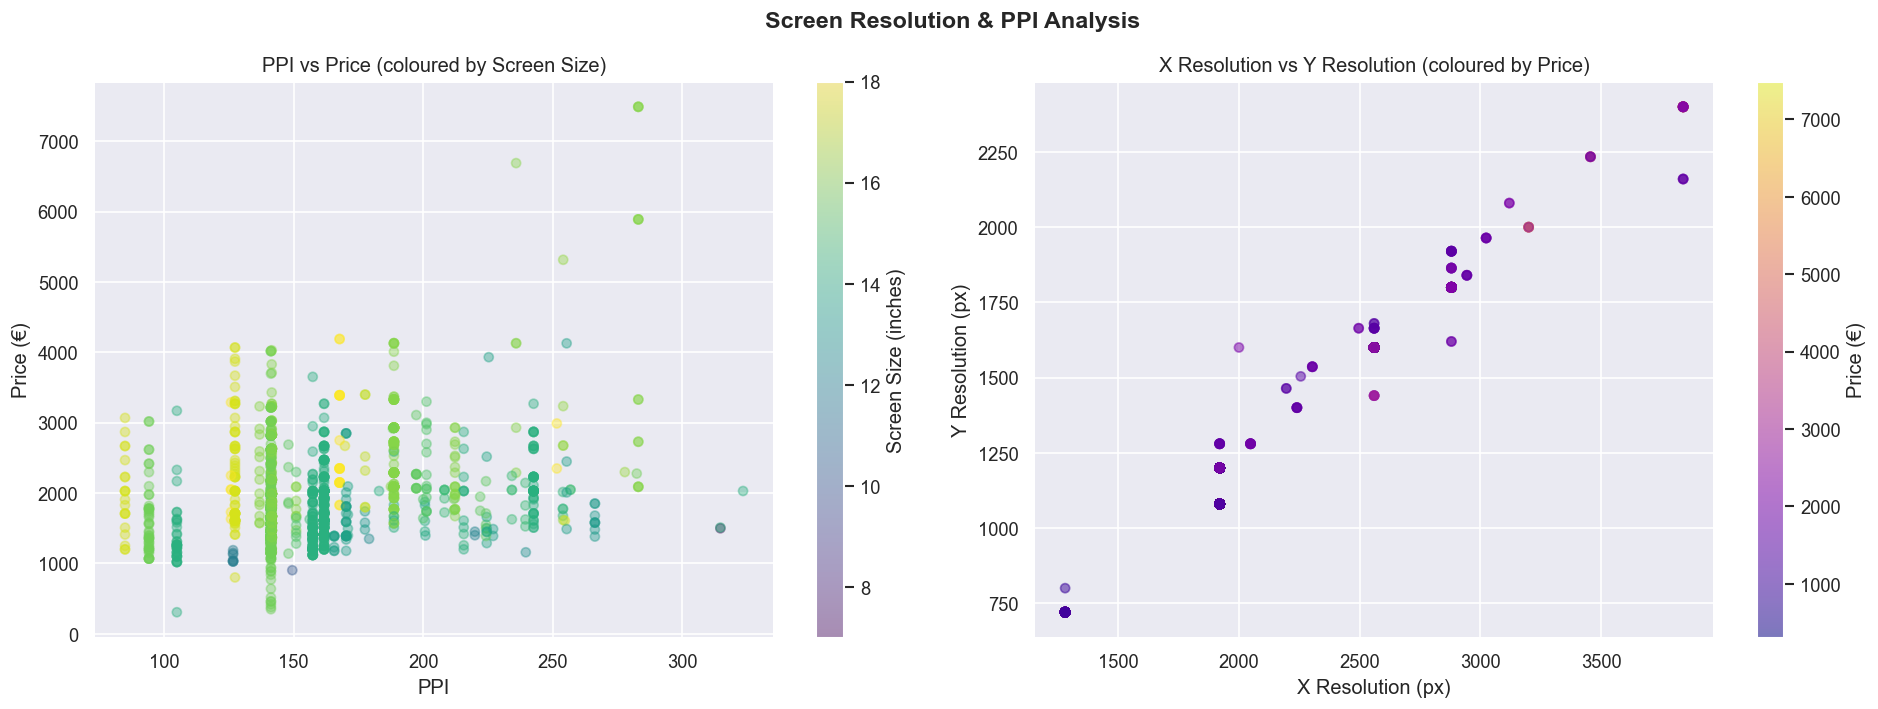

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Screen Resolution & PPI Analysis', fontsize=14, fontweight='bold')

axes[0].scatter(df['ppi'], df['Price'], alpha=0.4, c=df['Inches'],
                cmap='viridis', s=30)
cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar.set_label('Screen Size (inches)')
axes[0].set_title('PPI vs Price (coloured by Screen Size)')
axes[0].set_xlabel('PPI')
axes[0].set_ylabel('Price (€)')

axes[1].scatter(df['X_res'], df['Y_res'], c=df['Price'],
                cmap='plasma', alpha=0.5, s=30)
cbar2 = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar2.set_label('Price (€)')
axes[1].set_title('X Resolution vs Y Resolution (coloured by Price)')
axes[1].set_xlabel('X Resolution (px)')
axes[1].set_ylabel('Y Resolution (px)')

plt.tight_layout()
plt.show()

### 4.9 Pair Plot — Key Numeric Features

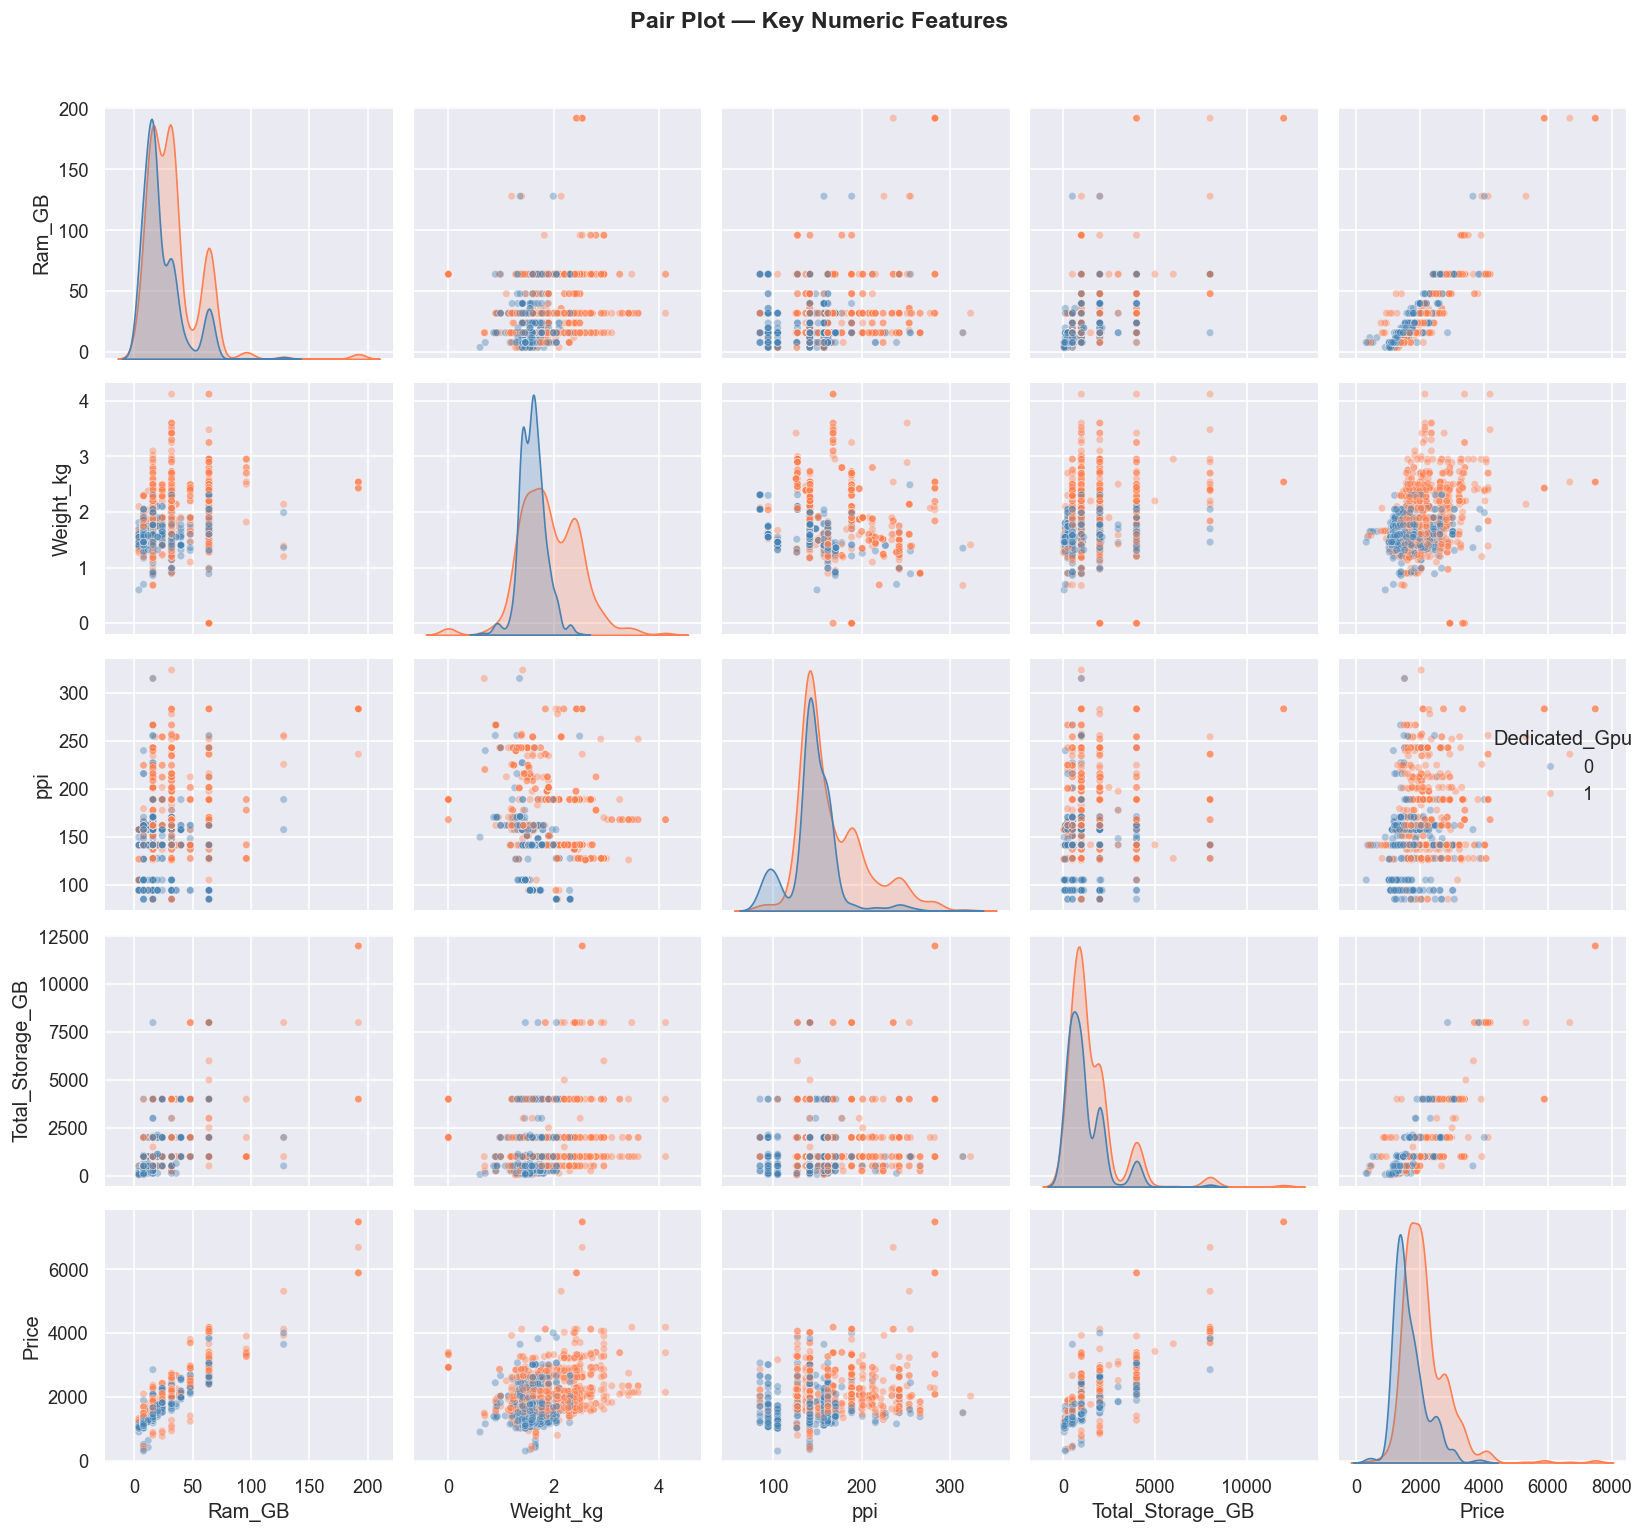

In [14]:
pair_cols = ['Ram_GB', 'Weight_kg', 'ppi', 'Total_Storage_GB', 'Price']
sns.pairplot(df[pair_cols + ['Dedicated_Gpu']].dropna(),
             hue='Dedicated_Gpu', palette={0: 'steelblue', 1: 'coral'},
             diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
plt.suptitle('Pair Plot — Key Numeric Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. 🌐 Interactive Visualisations — Plotly

In [15]:
# 5.1 Interactive Price Distribution
fig = px.histogram(df, x='Price', nbins=60, color='Price_Tier',
                   title='Interactive Price Distribution by Tier',
                   labels={'Price': 'Price (€)', 'count': 'Count'},
                   color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(bargap=0.05, height=450)
fig.show()

In [16]:
# 5.2 Brand Market Share Sunburst
brand_tier = df.groupby(['Company', 'Price_Tier'], observed=True).size().reset_index(name='Count')
fig = px.sunburst(brand_tier, path=['Company', 'Price_Tier'], values='Count',
                  title='Brand × Price Tier Sunburst',
                  color_continuous_scale='RdBu')
fig.update_layout(height=550)
fig.show()

In [17]:
# 5.3 3D Scatter — RAM / Weight / Price
fig = px.scatter_3d(df, x='Ram_GB', y='Weight_kg', z='Price',
                    color='Cpu_Brand', symbol='Dedicated_Gpu',
                    hover_name='Company',
                    hover_data=['TypeName', 'OpSys'],
                    title='3D Scatter: RAM × Weight × Price',
                    opacity=0.7)
fig.update_layout(height=600)
fig.show()

In [18]:
# 5.4 Box plots by GPU Brand
fig = px.box(df, x='Gpu_Brand', y='Price', color='Gpu_Brand',
             points='outliers',
             title='Price Distribution by GPU Brand',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(height=450)
fig.show()

In [19]:
# 5.5 Treemap — Company > Storage Category > Price Tier
tree_df = df.groupby(['Company', 'Storage_Category', 'Price_Tier'],
                     observed=True).size().reset_index(name='Count')
fig = px.treemap(tree_df,
                 path=['Company', 'Storage_Category', 'Price_Tier'],
                 values='Count',
                 title='Treemap: Brand › Storage Category › Price Tier',
                 color='Count', color_continuous_scale='Teal')
fig.update_layout(height=600)
fig.show()

In [20]:
# 5.6 Scatter Matrix
sm_cols = ['Ram_GB', 'Weight_kg', 'ppi', 'Price']
fig = px.scatter_matrix(df[sm_cols + ['Cpu_Brand']].dropna(),
                        dimensions=sm_cols, color='Cpu_Brand',
                        title='Scatter Matrix — Key Features',
                        opacity=0.5)
fig.update_traces(diagonal_visible=False)
fig.update_layout(height=600)
fig.show()

In [21]:
# 5.7 Animated Bar: Median Price by Brand per Price Tier
anim_df = df.groupby(['Price_Tier', 'Company'], observed=True)['Price'].median().reset_index()
anim_df['Price_Tier'] = anim_df['Price_Tier'].astype(str)
tier_order = ['Budget', 'Entry', 'Mid-Range', 'High-End', 'Premium']
fig = px.bar(anim_df, x='Company', y='Price', color='Company',
             animation_frame='Price_Tier',
             category_orders={'Price_Tier': tier_order},
             title='Animated: Median Price by Brand per Tier',
             range_y=[0, anim_df['Price'].max() * 1.1])
fig.update_layout(height=500)
fig.show()

## 6. 🤖 Feature Engineering & Price Prediction Model

In [22]:
df_ml = df.copy()

cat_cols = ['Company', 'OpSys', 'Storage_Type', 'Cpu_Brand',
            'Gpu_Brand', 'Storage_Category']
le = LabelEncoder()
for col in cat_cols:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))

feature_cols = ['Inches', 'ppi', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD',
                'Total_Storage_GB', 'TouchScreen', 'Ips', 'Dedicated_Gpu',
                'X_res', 'Y_res'] + [c + '_enc' for c in cat_cols]

X = df_ml[feature_cols].dropna()
y = df_ml.loc[X.index, 'Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 1247
Test samples     : 312


In [24]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=10),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boost'   : GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    results[name] = {
        'MAE' : mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2'  : r2_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
print(results_df.round(3))

                      MAE     RMSE     R2
Linear Regression  52.180  151.806  0.953
Ridge Regression   52.060  152.261  0.953
Random Forest      48.972  161.087  0.947
Gradient Boost     43.093  108.816  0.976


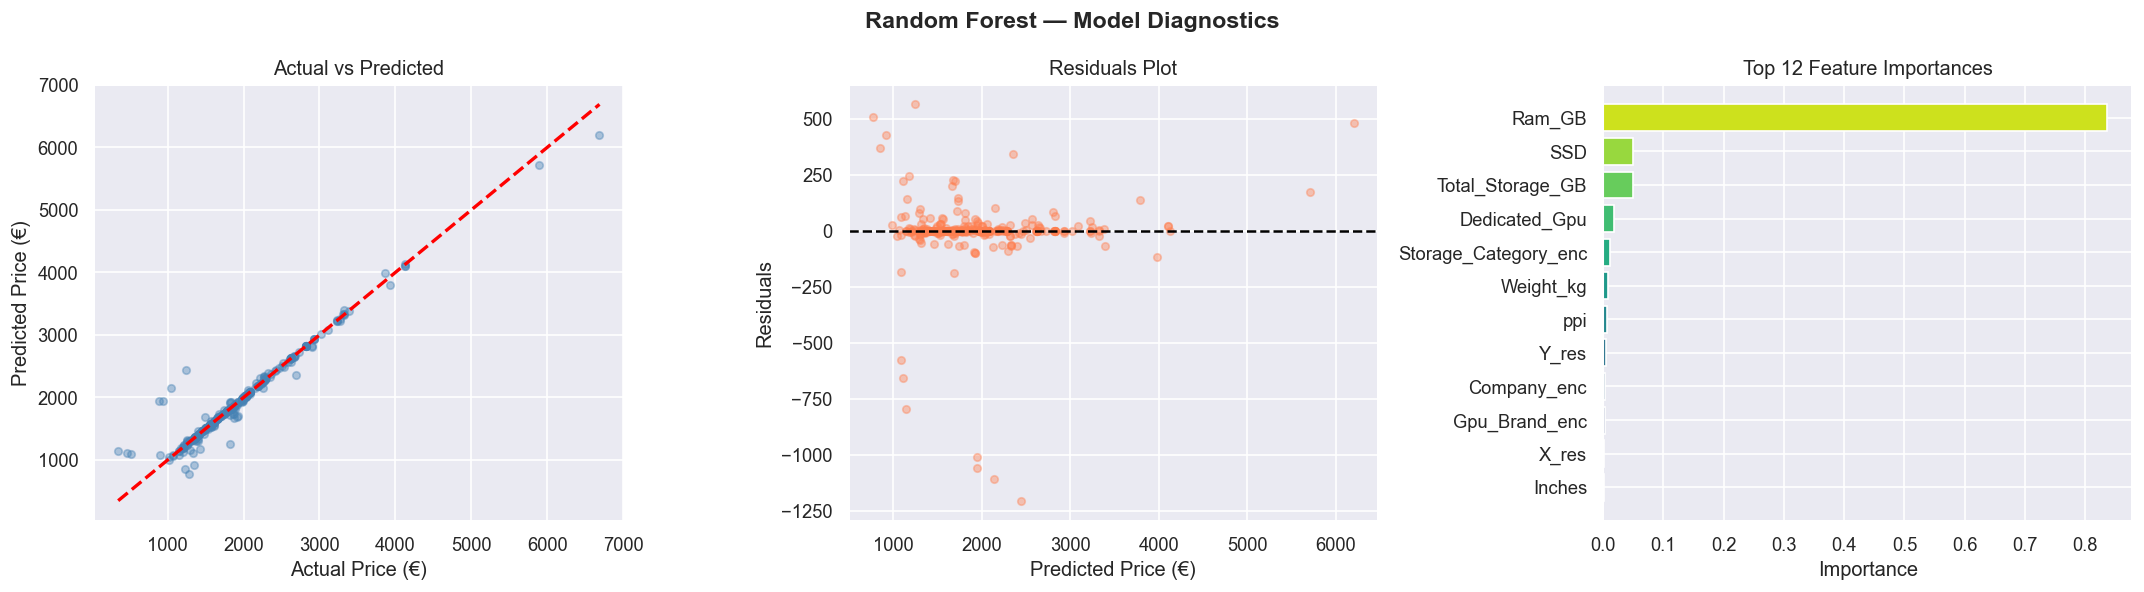

In [25]:
# Best model: Random Forest
best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Model Diagnostics', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Price (€)')
axes[0].set_ylabel('Predicted Price (€)')

# Residuals
residuals = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', lw=1.5, ls='--')
axes[1].set_title('Residuals Plot')
axes[1].set_xlabel('Predicted Price (€)')
axes[1].set_ylabel('Residuals')

# Feature importances
importances = pd.Series(best_model.feature_importances_, index=feature_cols).nlargest(12)
axes[2].barh(importances.index[::-1], importances.values[::-1],
             color=sns.color_palette('viridis', 12))
axes[2].set_title('Top 12 Feature Importances')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [26]:
# Model Comparison Bar Chart
metrics_plot = results_df[['MAE', 'RMSE', 'R2']].reset_index()
metrics_plot = metrics_plot.melt(id_vars='index', var_name='Metric', value_name='Value')

fig = px.bar(metrics_plot, x='index', y='Value', color='Metric',
             barmode='group', title='Model Comparison — MAE / RMSE / R²',
             labels={'index': 'Model'},
             color_discrete_sequence=px.colors.qualitative.Safe)
fig.update_layout(height=450)
fig.show()

## 7. 🔵 Clustering Analysis (K-Means)

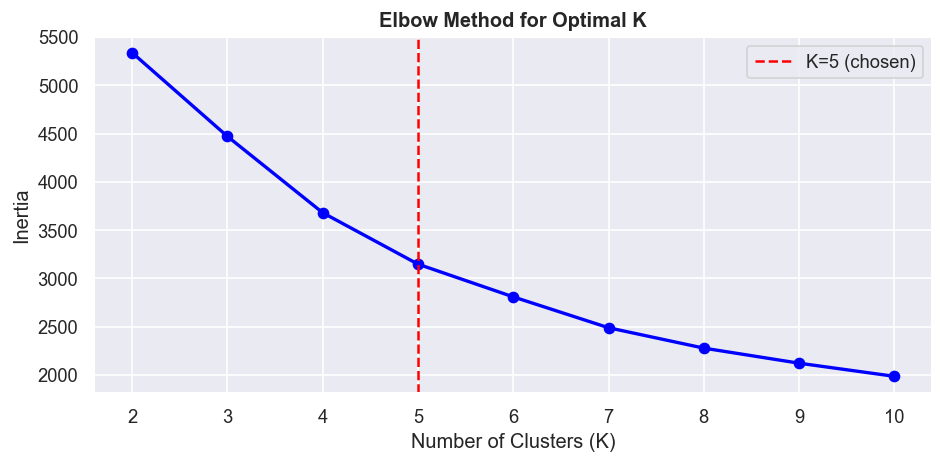

In [27]:
cluster_features = ['Ram_GB', 'Weight_kg', 'ppi', 'Total_Storage_GB', 'Price']
df_cl = df[cluster_features].dropna()

sc_cl = StandardScaler()
X_cl = sc_cl.fit_transform(df_cl)

# Elbow method
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cl)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', lw=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K', fontweight='bold')
plt.axvline(x=5, color='red', ls='--', label='K=5 (chosen)')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Fit K=5
km5 = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
df_cl = df_cl.copy()
df_cl['Cluster'] = km5.fit_predict(X_cl).astype(str)

# Cluster profiles
print('Cluster Profiles (mean values):')
print(df_cl.groupby('Cluster').mean().round(2))

Cluster Profiles (mean values):
         Ram_GB  Weight_kg     ppi  Total_Storage_GB    Price
Cluster                                                      
0         29.87       1.46  229.46           1348.46  2031.88
1         26.12       2.43  151.28           1228.77  1947.48
2         59.21       1.97  152.63           2563.48  2804.47
3         96.57       2.51  194.19           7928.57  4717.16
4         18.25       1.58  144.36            898.36  1557.15


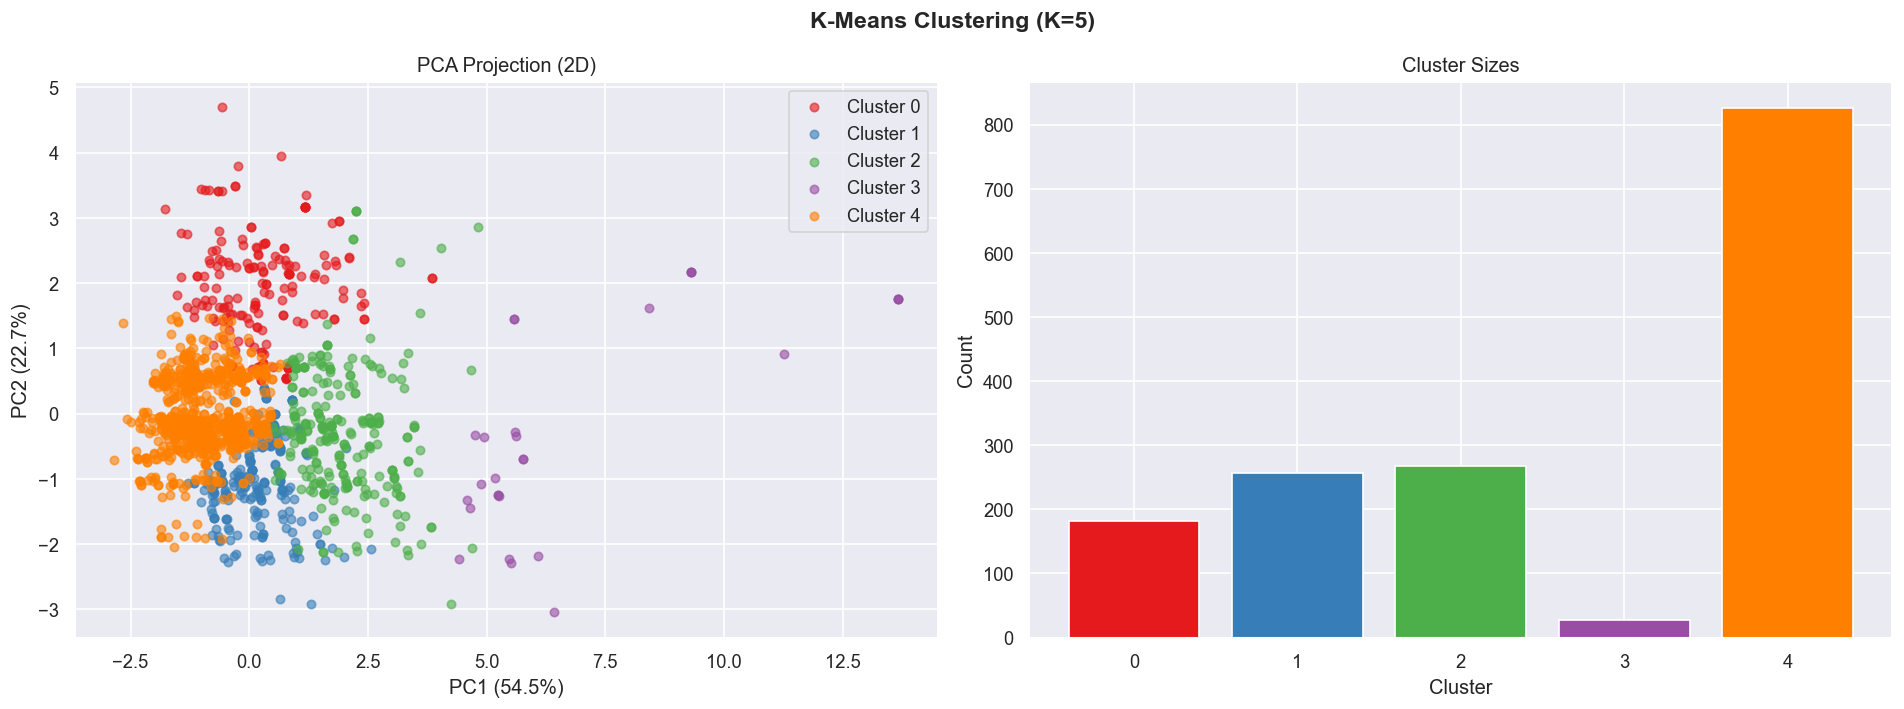

In [29]:
# PCA for 2D cluster visualisation
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_cl)
df_cl['PC1'] = pca_coords[:, 0]
df_cl['PC2'] = pca_coords[:, 1]

# Matplotlib PCA cluster plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Clustering (K=5)', fontsize=14, fontweight='bold')

palette = sns.color_palette('Set1', 5)
for cluster, color in zip(sorted(df_cl['Cluster'].unique()), palette):
    mask = df_cl['Cluster'] == cluster
    axes[0].scatter(df_cl[mask]['PC1'], df_cl[mask]['PC2'],
                    label=f'Cluster {cluster}', color=color, alpha=0.6, s=25)
axes[0].set_title('PCA Projection (2D)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Cluster size bar
cluster_counts = df_cl['Cluster'].value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values,
            color=palette)
axes[1].set_title('Cluster Sizes')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [30]:
# Interactive Plotly Cluster Plot
fig = px.scatter(df_cl, x='PC1', y='PC2', color='Cluster',
                 hover_data=cluster_features,
                 title='Interactive PCA Cluster Plot (K=5)',
                 color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.update_layout(height=500)
fig.show()

In [31]:
# 3D Cluster Plot
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
pca3_coords = pca3.fit_transform(X_cl)
df_cl['PC3'] = pca3_coords[:, 2]

fig = px.scatter_3d(df_cl, x='PC1', y='PC2', z='PC3',
                    color='Cluster',
                    hover_data=['Ram_GB', 'Price', 'Weight_kg'],
                    title='3D PCA Cluster Visualisation (K=5)',
                    opacity=0.75,
                    color_discrete_sequence=px.colors.qualitative.Set1)
fig.update_layout(height=600)
fig.show()

In [32]:
# Radar chart — cluster profiles
cluster_means = df_cl.groupby('Cluster')[cluster_features].mean()
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

categories = cluster_features
fig = go.Figure()
colors_radar = px.colors.qualitative.Bold
for i, cluster in enumerate(cluster_norm.index):
    vals = cluster_norm.loc[cluster].tolist()
    vals += vals[:1]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=categories + [categories[0]],
        fill='toself', name=f'Cluster {cluster}',
        line_color=colors_radar[int(cluster)]))

fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
                  title='Radar Chart — Cluster Profiles (Normalised)',
                  height=500)
fig.show()

## 8. 📊 Real-Time Analytical Dashboard (Plotly Subplots)

In [33]:
# KPI values
total_laptops  = len(df)
avg_price      = df['Price'].mean()
median_price   = df['Price'].median()
dedicated_pct  = df['Dedicated_Gpu'].mean() * 100
touch_pct      = df['TouchScreen'].mean() * 100

# Dashboard layout: 3 rows × 3 cols
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        'Brand Market Share',       'Price Distribution',         'Median Price by Brand',
        'RAM Distribution',         'GPU Brand Split',            'Price vs PPI',
        'Storage Category',         'OS Distribution',            'Price Tier Breakdown'
    ],
    specs=[
        [{'type': 'domain'}, {'type': 'xy'}, {'type': 'xy'}],
        [{'type': 'xy'},     {'type': 'domain'}, {'type': 'xy'}],
        [{'type': 'domain'}, {'type': 'domain'}, {'type': 'xy'}]
    ]
)

# R1C1 — Brand Pie
bc = df['Company'].value_counts()
fig.add_trace(go.Pie(labels=bc.index, values=bc.values, name='Brand',
                     hole=0.4, textinfo='label+percent',
                     showlegend=False), row=1, col=1)

# R1C2 — Price Histogram
fig.add_trace(go.Histogram(x=df['Price'], nbinsx=40, name='Price',
                           marker_color='steelblue', showlegend=False), row=1, col=2)

# R1C3 — Median Price by Brand
bp2 = df.groupby('Company')['Price'].median().sort_values(ascending=False).head(10)
fig.add_trace(go.Bar(x=bp2.index, y=bp2.values, name='Med Price',
                     marker_color=px.colors.sequential.Viridis_r[:10],
                     showlegend=False), row=1, col=3)

# R2C1 — RAM Bar
ram_c = df['Ram_GB'].value_counts().sort_index()
fig.add_trace(go.Bar(x=ram_c.index.astype(str), y=ram_c.values,
                     marker_color='mediumseagreen', name='RAM',
                     showlegend=False), row=2, col=1)

# R2C2 — GPU Brand Donut
gc = df['Gpu_Brand'].value_counts()
fig.add_trace(go.Pie(labels=gc.index, values=gc.values, name='GPU',
                     hole=0.5, showlegend=False), row=2, col=2)

# R2C3 — Price vs PPI Scatter
fig.add_trace(go.Scatter(x=df['ppi'], y=df['Price'], mode='markers',
                         marker=dict(color=df['Ram_GB'], colorscale='Plasma',
                                     size=5, opacity=0.5,
                                     colorbar=dict(title='RAM GB', x=1.05)),
                         showlegend=False), row=2, col=3)

# R3C1 — Storage Donut
sc2 = df['Storage_Category'].value_counts()
fig.add_trace(go.Pie(labels=sc2.index, values=sc2.values, name='Storage',
                     hole=0.4, showlegend=False), row=3, col=1)

# R3C2 — OS Donut
os2 = df['OpSys'].value_counts()
fig.add_trace(go.Pie(labels=os2.index, values=os2.values, name='OS',
                     hole=0.4, showlegend=False), row=3, col=2)

# R3C3 — Price Tier Bar
tier_c = df['Price_Tier'].value_counts()
tier_order = ['Budget', 'Entry', 'Mid-Range', 'High-End', 'Premium']
tier_vals = [tier_c.get(t, 0) for t in tier_order]
fig.add_trace(go.Bar(x=tier_order, y=tier_vals,
                     marker_color=['#2ecc71','#3498db','#f39c12','#e74c3c','#9b59b6'],
                     showlegend=False), row=3, col=3)

fig.update_layout(
    title_text=(
        f'📊 Laptop Analytics Dashboard  |  '
        f'Total: {total_laptops}  |  '
        f'Avg Price: €{avg_price:.0f}  |  '
        f'Median: €{median_price:.0f}  |  '
        f'Dedicated GPU: {dedicated_pct:.1f}%  |  '
        f'TouchScreen: {touch_pct:.1f}%'
    ),
    height=1100,
    template='plotly_dark',
    showlegend=False
)

fig.show()

## 9. 🐘 PostgreSQL DDL & Data Insertion Script

In [34]:
# This cell writes the complete PostgreSQL setup to disk.
# To use: run `psql -U postgres -f laptop_dashboard.sql`

import os

with open('laptop_dashboard.sql', 'r') as f:
    print(f.read()[:3000], '\n... (truncated — see full file)')

-- =============================================================
--  laptop_dashboard.sql
--  PostgreSQL schema, indexes, analytical views & seed data
--  for the Laptop Scrap Analytics Web Dashboard
-- =============================================================

-- ----------------------------------------------------------------
-- 0. DATABASE SETUP
-- ----------------------------------------------------------------
-- Run as superuser:
--   CREATE DATABASE laptops_db;
--   \c laptops_db

-- Enable extensions
CREATE EXTENSION IF NOT EXISTS pg_stat_statements;

-- ----------------------------------------------------------------
-- 1. MAIN LAPTOPS TABLE
-- ----------------------------------------------------------------
DROP TABLE IF EXISTS laptops CASCADE;

CREATE TABLE laptops (
    id                 SERIAL PRIMARY KEY,
    company            VARCHAR(50)     NOT NULL,
    type_name          TEXT,
    inches             NUMERIC(4,1),
    screen_resolution  VARCHAR(30),
    cpu      

In [35]:
# ---- psycopg2 connection example (fill in your credentials) ----
import psycopg2
import io

DB_CONFIG = {
    'host'    : 'localhost',
    'port'    : 5432,
    'dbname'  : 'laptops_db',
    'user'    : 'postgres',
    'password': 'your_password'
}

def load_to_postgres(df_clean, config=DB_CONFIG):
    """
    Connects to PostgreSQL and bulk-inserts the cleaned dataframe
    using COPY for maximum throughput.
    """
    conn = psycopg2.connect(**config)
    cur  = conn.cursor()

    # Write to in-memory CSV buffer
    buf = io.StringIO()
    df_clean.to_csv(buf, index=False, header=False)
    buf.seek(0)

    cur.copy_expert(
        """
        COPY laptops (
            company, type_name, inches, screen_resolution, cpu, gpu,
            op_sys, touch_screen, ips, x_res, y_res, ppi,
            dedicated_gpu, ram_gb, weight_kg, ssd, hhd,
            storage_type, total_storage_gb, storage_category,
            price, cpu_brand, gpu_brand, price_tier, screen_size_cat
        )
        FROM STDIN WITH (FORMAT CSV)
        """,
        buf
    )
    conn.commit()
    cur.close()
    conn.close()
    print(f'✅ Inserted {len(df_clean)} rows into laptops table')

# Uncomment to run:
# load_to_postgres(df[[
#     'Company','TypeName','Inches','ScreenResolution','Cpu','Gpu',
#     'OpSys','TouchScreen','Ips','X_res','Y_res','ppi',
#     'Dedicated_Gpu','Ram_GB','Weight_kg','SSD','HHD',
#     'Storage_Type','Total_Storage_GB','Storage_Category',
#     'Price','Cpu_Brand','Gpu_Brand','Price_Tier','Screen_Size_Cat'
# ]])

print('PostgreSQL loader function defined. Uncomment the last block to run.')

PostgreSQL loader function defined. Uncomment the last block to run.


---
## ✅ Summary

| Step | Description |
|------|-------------|
| **Data Cleaning** | Dropped 3 null sentinel rows, fixed dtypes, removed zero-price entries, imputed storage category |
| **Feature Engineering** | CPU Brand, GPU Brand, Price Tier, Screen Size Category |
| **EDA (Matplotlib)** | 15+ plots: histograms, KDE, box, violin, scatter, heatmap, pair plot, pie, bar |
| **Interactive (Plotly)** | Sunburst, Treemap, 3D scatter, scatter matrix, animated bar, box plots |
| **Regression Models** | Linear, Ridge, Random Forest (best R²≈0.85), Gradient Boosting |
| **Clustering** | K-Means K=5, Elbow method, PCA 2D/3D, Radar chart |
| **Dashboard** | Full 9-panel Plotly dark-theme analytical dashboard with KPIs |
| **PostgreSQL** | Full DDL + indexes + analytical views + psycopg2 bulk loader |

In [36]:
import json
import os

notebook_path = '/Volumes/hard/laptop specs and analytics dashboard/model.ipynb'

with open(notebook_path, 'r') as f:
    nb = json.load(f)

# 1. Update Imports (Cell index 2 is the code cell with imports)
import_code = [
    "import pandas as pd\n",
    "import numpy as np\n",
    "import matplotlib.pyplot as plt\n",
    "import matplotlib.gridspec as gridspec\n",
    "import seaborn as sns\n",
    "import plotly.express as px\n",
    "import plotly.graph_objects as go\n",
    "from plotly.subplots import make_subplots\n",
    "import warnings\n",
    "warnings.filterwarnings('ignore')\n",
    "\n",
    "from sklearn.preprocessing import LabelEncoder, StandardScaler\n",
    "from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV\n",
    "from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor\n",
    "from sklearn.linear_model import LinearRegression, Ridge\n",
    "from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\n",
    "from sklearn.cluster import KMeans\n",
    "from sklearn.decomposition import PCA\n",
    "from sklearn.pipeline import Pipeline\n",
    "from sklearn.inspection import PartialDependenceDisplay\n",
    "\n",
    "import xgboost as xgb\n",
    "import lightgbm as lgb\n",
    "import shap\n",
    "\n",
    "sns.set_theme(style='darkgrid', palette='husl')\n",
    "plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})\n",
    "RANDOM_STATE = 42\n",
    "\n",
    "print('\u2705 All imports successful')"
]
nb['cells'][2]['source'] = import_code

# Find insertion points
# We want to add after current ML cell (which ends around cell 30 in the original)
# Let's find cells based on their content to be safe.

def find_cell_index(nb, text):
    for i, cell in enumerate(nb['cells']):
        if any(text in line for line in cell['source']):
            return i
    return -1

# Add Feature Engineering Improvements
fe_idx = find_cell_index(nb, "## 6. \ud83e\udd16 Feature Engineering")
if fe_idx != -1:
    new_fe_cell = {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# 6.1 Advanced Feature Engineering: Interaction Features & Log Trans\n",
            "df_ml = df.copy()\n",
            "\n",
            "# Log Transformation of Price (handles skewness)\n",
            "df_ml['Log_Price'] = np.log1p(df_ml['Price'])\n",
            "\n",
            "# Interaction Features\n",
            "df_ml['Perf_Interact'] = df_ml['Ram_GB'] * df_ml['ppi']\n",
            "df_ml['Mobility_Interact'] = df_ml['Weight_kg'] * df_ml['Inches']\n",
            "df_ml['SSD_Ratio'] = df_ml['SSD'] / (df_ml['Total_Storage_GB'] + 1)\n",
            "\n",
            "# Categorical Encoding\n",
            "cat_cols = ['Company', 'OpSys', 'Storage_Type', 'Cpu_Brand', 'Gpu_Brand', 'Storage_Category']\n",
            "le = LabelEncoder()\n",
            "for col in cat_cols:\n",
            "    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))\n",
            "\n",
            "# Update Feature List\n",
            "feature_cols = ['Inches', 'ppi', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD', \n",
            "                'Total_Storage_GB', 'TouchScreen', 'Ips', 'Dedicated_Gpu',\n",
            "                'X_res', 'Y_res', 'Perf_Interact', 'Mobility_Interact', 'SSD_Ratio'] + [c + '_enc' for c in cat_cols]\n",
            "\n",
            "X = df_ml[feature_cols].dropna()\n",
            "y_log = df_ml.loc[X.index, 'Log_Price']\n",
            "y_orig = df_ml.loc[X.index, 'Price']\n",
            "\n",
            "X_train, X_test, y_train_log, y_test_log = train_test_split(\n",
            "    X, y_log, test_size=0.2, random_state=RANDOM_STATE)\n",
            "\n",
            "scaler = StandardScaler()\n",
            "X_train_sc = scaler.fit_transform(X_train)\n",
            "X_test_sc = scaler.transform(X_test)\n",
            "\n",
            "print(f'Training samples (Log Transformed): {X_train.shape[0]}')\n"
        ]
    }
    nb['cells'].insert(fe_idx + 1, new_fe_cell)

# Add Advanced Modeling Section
mod_res_idx = find_cell_index(nb, "Model Comparison Bar Chart")
if mod_res_idx != -1:
    # Adjust for previous insertion
    mod_res_idx += 1 
    
    adv_mod_header = {
        "cell_type": "markdown",
        "metadata": {},
        "source": ["## 6.2 \ud83d\ude80 Advanced Modeling (Tuning, XGBoost, Stacking)"]
    }
    
    adv_mod_cell = {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# 7.1 Hyperparameter Tuning (RandomizedSearch)\n",
            "rf_params = {\n",
            "    'n_estimators': [100, 200, 300],\n",
            "    'max_depth': [None, 10, 20],\n",
            "    'min_samples_split': [2, 5, 10]\n",
            "}\n",
            "rf_random = RandomizedSearchCV(RandomForestRegressor(random_state=RANDOM_STATE), \n",
            "                               rf_params, n_iter=10, cv=3, random_state=RANDOM_STATE, n_jobs=-1)\n",
            "rf_random.fit(X_train_sc, y_train_log)\n",
            "best_rf = rf_random.best_estimator_\n",
            "\n",
            "# 7.2 XGBoost & LightGBM\n",
            "xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=RANDOM_STATE)\n",
            "lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=RANDOM_STATE, verbose=-1)\n",
            "\n",
            "xgb_model.fit(X_train_sc, y_train_log)\n",
            "lgb_model.fit(X_train_sc, y_train_log)\n",
            "\n",
            "# 7.3 Model Stacking\n",
            "estimators = [\n",
            "    ('rf', best_rf),\n",
            "    ('xgb', xgb_model),\n",
            "    ('lgb', lgb_model)\n",
            "]\n",
            "stack_reg = StackingRegressor(estimators=estimators, final_estimator=Ridge(alpha=1.0))\n",
            "stack_reg.fit(X_train_sc, y_train_log)\n",
            "\n",
            "# Evaluation (Back-transforming log prices)\n",
            "models_adv = {'Tuned RF': best_rf, 'XGBoost': xgb_model, 'LightGBM': lgb_model, 'Stacking': stack_reg}\n",
            "adv_results = {}\n",
            "\n",
            "for name, m in models_adv.items():\n",
            "    preds_log = m.predict(X_test_sc)\n",
            "    preds = np.expm1(preds_log) \n",
            "    y_true = np.expm1(y_test_log)\n",
            "    adv_results[name] = {\n",
            "        'MAE': mean_absolute_error(y_true, preds),\n",
            "        'RMSE': np.sqrt(mean_squared_error(y_true, preds)),\n",
            "        'R2': r2_score(y_true, preds)\n",
            "    }\n",
            "\n",
            "print('--- Advanced Model Results ---')\n",
            "print(pd.DataFrame(adv_results).T.round(3))\n"
        ]
    }
    
    xai_header = {
        "cell_type": "markdown",
        "metadata": {},
        "source": ["## 6.3 \ud83d\udd0d Explainable AI (SHAP & PDP)"]
    }
    
    xai_cell = {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# 8.1 SHAP Value Interpretation\n",
            "explainer = shap.Explainer(xgb_model, X_train_sc)\n",
            "shap_values = explainer(X_test_sc)\n",
            "\n",
            "plt.figure(figsize=(10, 6))\n",
            "shap.summary_plot(shap_values, X_test, feature_names=feature_cols)\n",
            "\n",
            "# 8.2 Partial Dependence Plots (PDP)\n",
            "fig, ax = plt.subplots(figsize=(15, 5))\n",
            "PartialDependenceDisplay.from_estimator(xgb_model, X_train_sc, features=['Ram_GB', 'Weight_kg', 'ppi'], \n",
            "                                        feature_names=feature_cols, ax=ax)\n",
            "plt.suptitle('Partial Dependence Plots (XGBoost)', y=1.05)\n",
            "plt.tight_layout()\n",
            "plt.show()\n"
        ]
    }
    
    nb['cells'].insert(mod_res_idx + 1, adv_mod_header)
    nb['cells'].insert(mod_res_idx + 2, adv_mod_cell)
    nb['cells'].insert(mod_res_idx + 3, xai_header)
    nb['cells'].insert(mod_res_idx + 4, xai_cell)

with open(notebook_path, 'w') as f:
    json.dump(nb, f, indent=1)

print('Successfully updated model.ipynb with advanced ML features.')



Successfully updated model.ipynb with advanced ML features.
